In [36]:
import pandas as pd
import sklearn.cluster as cluster
import matplotlib.pyplot as plt

In [37]:
#Učitavamo dataset sa svim podacima i oučavamo kolone kao i tipove kolona
#Dakle vidimo da imamo 15 kolona od kojih su većina numeričke izuzev kolona Gender i Workout_Type
df_svi_clanovi = pd.read_csv('./data/gym_members_exercise_tracking.csv')
df_svi_clanovi.info()

<class 'pandas.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    str    
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    str    
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int64  
 13  E

In [38]:
#Prikaz nekoliko redova samog dataset-a
df_svi_clanovi.head(10)


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39
5,56,Female,58.0,1.68,168,156,74,1.59,1116.0,HIIT,15.5,2.7,5,3,20.55
6,36,Male,70.3,1.72,174,169,73,1.49,1385.0,Cardio,21.3,2.3,3,2,23.76
7,40,Female,69.7,1.51,189,141,64,1.27,895.0,Cardio,30.6,1.9,3,2,30.57
8,28,Male,121.7,1.94,185,127,52,1.03,719.0,Strength,28.9,2.6,4,2,32.34
9,28,Male,101.8,1.84,169,136,64,1.08,808.0,Cardio,29.7,2.7,3,1,30.07


In [39]:
#Dataset ćemo podeliti na dva podskupa  (Male, Female) - klasterizaciju ćemo sprovesti odvojeno za svaki podskup, s obzirom da se telesni parametri muških i ženskih članova značajno razlikuju.U ovoj skripti ce biti opisana klasterizacija za muške članove.

muski_clanovi = df_svi_clanovi[df_svi_clanovi["Gender"] == "Male"].copy()

In [40]:
#Sada vršimo ponovo pregled kolona i vidimo drugi broj redova,budući da više nemamo redove za ženske članove
muski_clanovi.info()
muski_clanovi.head(20)

<class 'pandas.DataFrame'>
Index: 511 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            511 non-null    int64  
 1   Gender                         511 non-null    str    
 2   Weight (kg)                    511 non-null    float64
 3   Height (m)                     511 non-null    float64
 4   Max_BPM                        511 non-null    int64  
 5   Avg_BPM                        511 non-null    int64  
 6   Resting_BPM                    511 non-null    int64  
 7   Session_Duration (hours)       511 non-null    float64
 8   Calories_Burned                511 non-null    float64
 9   Workout_Type                   511 non-null    str    
 10  Fat_Percentage                 511 non-null    float64
 11  Water_Intake (liters)          511 non-null    float64
 12  Workout_Frequency (days/week)  511 non-null    int64  
 13  Experi

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39
6,36,Male,70.3,1.72,174,169,73,1.49,1385.0,Cardio,21.3,2.3,3,2,23.76
8,28,Male,121.7,1.94,185,127,52,1.03,719.0,Strength,28.9,2.6,4,2,32.34
9,28,Male,101.8,1.84,169,136,64,1.08,808.0,Cardio,29.7,2.7,3,1,30.07
10,41,Male,120.8,1.67,188,146,54,0.82,593.0,HIIT,20.5,3.0,2,1,43.31
11,53,Male,51.7,1.70,175,152,72,1.15,865.0,HIIT,23.6,3.5,3,2,17.89
12,57,Male,112.5,1.61,195,165,61,1.24,1013.0,Cardio,22.1,2.7,3,2,43.40
13,41,Male,94.5,2.00,179,136,69,1.18,794.0,HIIT,27.6,3.7,3,1,23.62


In [41]:
#Sada kada dataset ima samo muške članove, prelazimo na sređivanje podataka, prvo ćemo razmotriti koje kolone bi možda trebalo izbaciti
#Prva kolona koju bi izbacili jeste Gender, nema smisla zadržati je posto su joj sve vrednosti iste, jer smo tako podelili dataset, zbog što validnijih rezultata klasterizacije
#U ovoj skripti ostavicemo promenljivu Workout_Type i ispitacemo slucaj da ta promenljiva ostane ukljucena i uporediti sa ostalim rezultatima
#Experience_Level izbacujemo iz klasterizacije jer zelimo da pronađemo grupe na osnovu fizičkih parametara, bez da unapred znamo koji je nivo iskustva - kasnije ćemo dobijene klastere uporediti sa ovom kolonom da vidimo da li se poklapaju, zato, je odvajamo sa strane
experience_level = muski_clanovi['Experience_Level']
# Izbacujemo kolone Gender i Expirience_level i vršimo OHC kolone Workout_Type, pa zatim ponovo pregled dataset-a:
muski_clanovi = pd.get_dummies(muski_clanovi, columns=['Workout_Type'])
#Nove OHC kolone su bool tipa (True/False), pa ih konvertujemo u numericki (int) tip
ohc_kolone = ['Workout_Type_Cardio', 'Workout_Type_HIIT', 'Workout_Type_Strength', 'Workout_Type_Yoga']
muski_clanovi[ohc_kolone] = muski_clanovi[ohc_kolone].astype(int)
muski_clanovi.drop(columns=["Gender", "Experience_Level"], inplace=True)

muski_clanovi.info()

<class 'pandas.DataFrame'>
Index: 511 entries, 0 to 972
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            511 non-null    int64  
 1   Weight (kg)                    511 non-null    float64
 2   Height (m)                     511 non-null    float64
 3   Max_BPM                        511 non-null    int64  
 4   Avg_BPM                        511 non-null    int64  
 5   Resting_BPM                    511 non-null    int64  
 6   Session_Duration (hours)       511 non-null    float64
 7   Calories_Burned                511 non-null    float64
 8   Fat_Percentage                 511 non-null    float64
 9   Water_Intake (liters)          511 non-null    float64
 10  Workout_Frequency (days/week)  511 non-null    int64  
 11  BMI                            511 non-null    float64
 12  Workout_Type_Cardio            511 non-null    int64  
 13  Workou

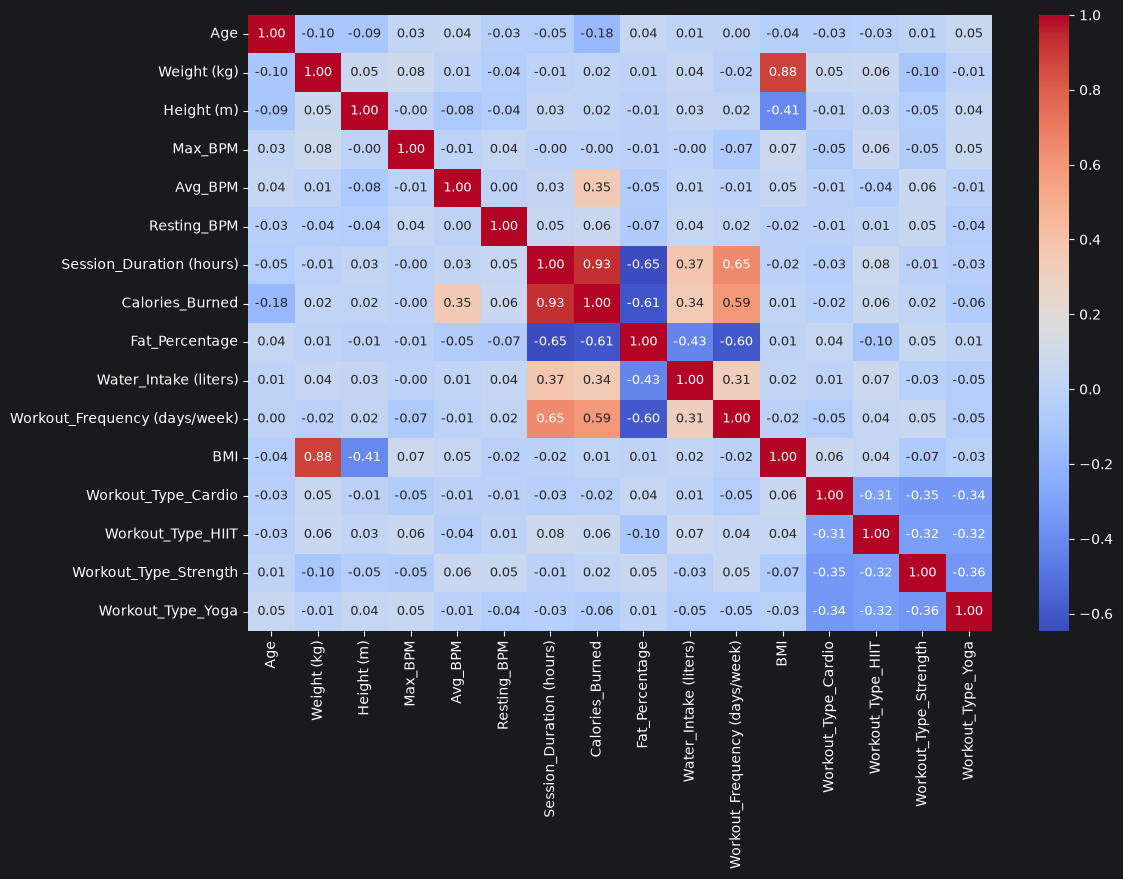

In [42]:
import seaborn as sb
#Što se tiče dalje pripreme podataka trebali bi da obratimo pažnju na NaN vrednosti ali u ovom dataset-u vidimo da istih nema ali važno je napomenuti da u slučaju da postoje NaN vrednosti, to bi se tretiralo na jedan od sledećih načina:
# 1.Izbacivanjem celih redova(ako neki red ima puno nedostajućih vrednosti)
# 2.Izbacivanjem celih promenljivih (ako neka promenljiva ima puno NaN vrednosti)
# 3.Zamenom NaN vrednosti npr. medijanom ili prosekom za tu promenljivu
# Dalje pošto su nam sve preostale promenljive numeričkog tipa nemamo potrebe da vršimo transformaciju kategorijskih promenljivih u numeričke
# Preostaje da proverimo korelacije između promenljivih


plt.figure(figsize=(12, 8))

sb.heatmap(muski_clanovi.corr(), annot=True,fmt=".2f",annot_kws={"size": 9},cmap="coolwarm")

plt.show()

In [43]:
#Dodavanjem Workout_Type kroz OHC, korelacije izmedju originalnih numerickih promenljivih ostaju identicne kao u osnovnoj analizi (BMI-Weight = 0.88, Session_Duration-Calories_Burned = 0.93), pa i dalje izbacujemo BMI i Calories_Burned iz istih razloga kao ranije.
#Nove Workout_Type kolone medjusobno pokazuju umerene negativne korelacije (oko -0.31 do -0.36), sto je ocekivano i matematicki neizbezno kod OHC-a (svaka osoba ima tacno jedan tip treninga, pa ako je jedna kolona 1, ostale su 0)
#Iz matrice vidimo dva para promenljivih za koje bi rekli da su velike korelacije:
# 1.Weight(kg) i Bmi sa vrednošću 0.88
# 2.Session_Duration i Calories_Burned sa vrednošću 0.93
# Sve ostale korelacije npr. Session_Duration-Fat_Percentage = -0.65, Workout_Frequency-Fat_Percentage = -0.60 su umerene,dakle nisu prešle prag od 0,7 ili 0,8 pa ne zahtevaju izbacivanje
#Izbacićemo promenljivu "BMI" jer je matematički izvedena iz Weight i Height (BMI = težina/visina²), pa ne nosi novu informaciju,a korelacija od 0.88 sa Weight to potvrđuje.
#Izbacujemo promenljivu "Calories_Burned" jer je broj sagorenih kalorija usko povezan sa dužinom treninga (korelacija 0.93)

muski_clanovi.drop(columns=["BMI", "Calories_Burned"], inplace=True)
muski_clanovi.info()

<class 'pandas.DataFrame'>
Index: 511 entries, 0 to 972
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            511 non-null    int64  
 1   Weight (kg)                    511 non-null    float64
 2   Height (m)                     511 non-null    float64
 3   Max_BPM                        511 non-null    int64  
 4   Avg_BPM                        511 non-null    int64  
 5   Resting_BPM                    511 non-null    int64  
 6   Session_Duration (hours)       511 non-null    float64
 7   Fat_Percentage                 511 non-null    float64
 8   Water_Intake (liters)          511 non-null    float64
 9   Workout_Frequency (days/week)  511 non-null    int64  
 10  Workout_Type_Cardio            511 non-null    int64  
 11  Workout_Type_HIIT              511 non-null    int64  
 12  Workout_Type_Strength          511 non-null    int64  
 13  Workou

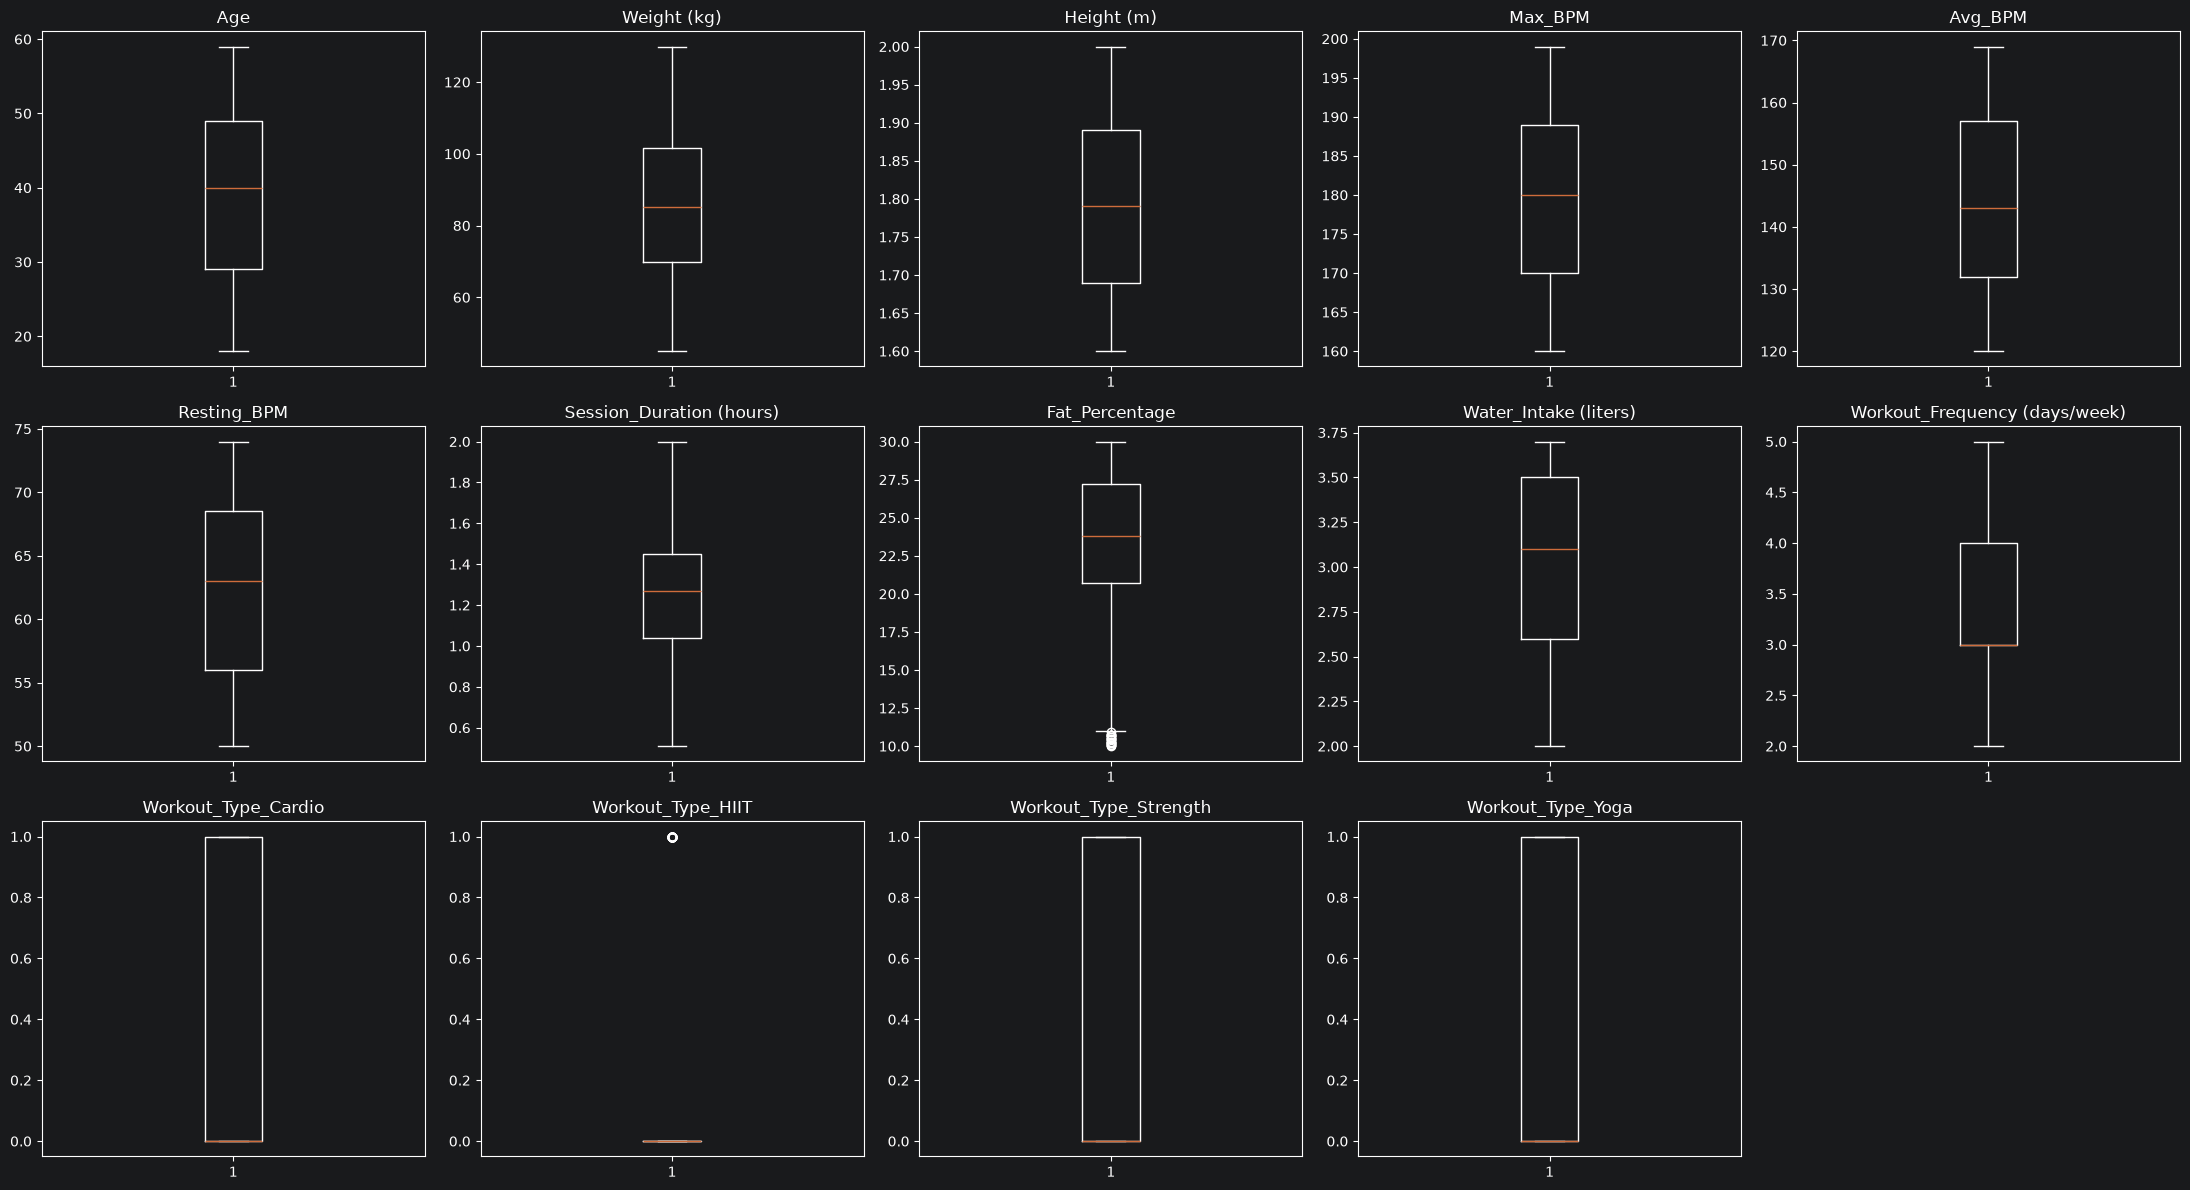

In [44]:
# Sledeće sto želimo da proverimo su outlier-i, pravimo poseban boxplot za svaku promenljivu, jer imaju veoma različite
# raspone vrednosti (npr. Weight ide do 129, a Height do 2), pa bi ih zajednički prikaz na istoj skali učinio nepreglednim
kolone = ["Age", "Weight (kg)", "Height (m)", "Max_BPM", "Avg_BPM",
          "Resting_BPM", "Session_Duration (hours)", "Fat_Percentage",
          "Water_Intake (liters)", "Workout_Frequency (days/week)",
          "Workout_Type_Cardio", "Workout_Type_HIIT", "Workout_Type_Strength", "Workout_Type_Yoga"]

fig, axes = plt.subplots(3, 5, figsize=(22, 12))

axes = axes.flatten()


for i, kolona in enumerate(kolone):
    axes[i].boxplot(muski_clanovi[kolona])
    axes[i].set_title(kolona)


for j in range(len(kolone), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

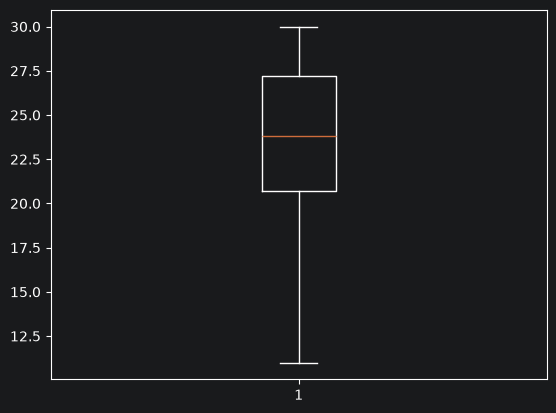

In [45]:
from scipy.stats.mstats import winsorize
import numpy as np
# Kod Workout_Type_HIIT boxplot prikazuje jedan outlier, ali ovo nije pravi outlier - radi se o binarnoj (0/1) promenljivoj, i ta tacka samo odrazava da je HIIT manje zastupljen tip treninga u datasetu.
#Vidimo da outlier-i postoje sa donje strane u koloni Fat_Percantage,a ostale kolone izgledaju okej
#Zato ćemo uraditi winsorization za tu promenljivu:

#Odozgo ne želimo ništa da odsecamo jer nemamo gore outlier-e vec dole,tako da je drugi parametar 0
wins = winsorize(muski_clanovi["Fat_Percentage"], limits = [0.04, 0])

plt.boxplot(wins)
plt.show()

#Kada se uradi winsorize od 0.96 do 0 percentila eliminišu se svi outlier-i


#Zamenjujemo sa winsorize vrednostima, stavljamo np.asarray zbog warning-a jer je funkcija winsorize vratila MaskedArray,pa Pandas izbacuje upozorenje kada izračunava kvantiile unutar .describe()
muski_clanovi["Fat_Percentage"]=np.asarray(wins)


In [46]:
from sklearn.preprocessing import MinMaxScaler
# Sledeće što je potrebno jeste izvršiti normalizaciju(skaliranje) promenljivih jer su na različitim rasponima vrednosti
# (npr. Weight do 129, Height do 2)

#Podaci pre normalizacije:
muski_clanovi.describe()






,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Workout_Type_Cardio,Workout_Type_HIIT,Workout_Type_Strength,Workout_Type_Yoga
count,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000
mean,38.998043,85.531115,1.793405,179.996086,143.898239,62.320939,1.252446,22.576712,3.007436,3.305284,0.252446,0.223092,0.264188,0.260274
std,12.045258,21.788629,0.117081,11.678873,14.300193,7.403943,0.344297,5.681986,0.494146,0.927125,0.434842,0.416727,0.441332,0.439214
min,18.000000,45.000000,1.600000,160.000000,120.000000,50.000000,0.510000,11.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,29.000000,69.750000,1.690000,170.000000,132.000000,56.000000,1.040000,20.700000,2.600000,3.000000,0.000000,0.000000,0.000000,0.000000
50%,40.000000,85.300000,1.790000,180.000000,143.000000,63.000000,1.270000,23.800000,3.100000,3.000000,0.000000,0.000000,0.000000,0.000000
75%,49.000000,101.600000,1.890000,189.000000,157.000000,68.500000,1.450000,27.200000,3.500000,4.000000,1.000000,0.000000,1.000000,1.000000
max,59.000000,129.900000,2.000000,199.000000,169.000000,74.000000,2.000000,30.000000,3.700000,5.000000,1.000000,1.000000,1.000000,1.000000


In [47]:
#Podaci nakon normalizacije
muski_clanovi = pd.DataFrame(MinMaxScaler().fit_transform(muski_clanovi), columns=muski_clanovi.columns)
muski_clanovi.describe()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Workout_Type_Cardio,Workout_Type_HIIT,Workout_Type_Strength,Workout_Type_Yoga
count,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000
mean,0.512147,0.477398,0.483513,0.512720,0.487719,0.513372,0.498286,0.609301,0.592610,0.435095,0.252446,0.223092,0.264188,0.260274
std,0.293787,0.256639,0.292703,0.299458,0.291841,0.308498,0.231071,0.299052,0.290674,0.309042,0.434842,0.416727,0.441332,0.439214
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.268293,0.291519,0.225000,0.256410,0.244898,0.250000,0.355705,0.510526,0.352941,0.333333,0.000000,0.000000,0.000000,0.000000
50%,0.536585,0.474676,0.475000,0.512821,0.469388,0.541667,0.510067,0.673684,0.647059,0.333333,0.000000,0.000000,0.000000,0.000000
75%,0.756098,0.666667,0.725000,0.743590,0.755102,0.770833,0.630872,0.852632,0.882353,0.666667,1.000000,0.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


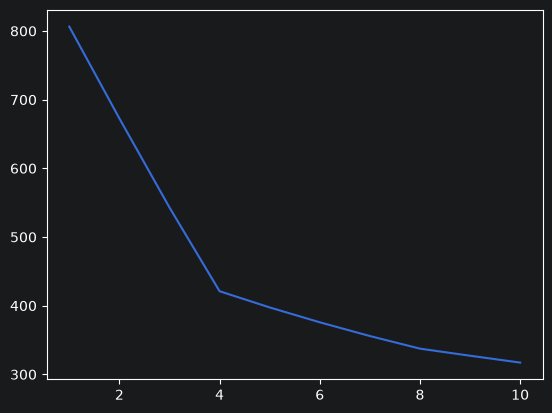

In [48]:
#Kada smo pripremili dataset za klasterizaciju, prvo ćemo obraditi kmeans klasterizaciju i prvo što je potrebno jeste da primenom elbow metode odredimo optimalno k
wcss = []

for i in range(1,11):
    kmeans = cluster.KMeans(n_clusters=i, init="k-means++", n_init= 1000, max_iter=100, random_state=0).fit(muski_clanovi)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.show()

k=2: silhouette score = 0.1745
k=3: silhouette score = 0.2571
k=4: silhouette score = 0.3362
k=5: silhouette score = 0.2942
k=6: silhouette score = 0.2678
k=7: silhouette score = 0.2456
k=8: silhouette score = 0.2195
k=9: silhouette score = 0.2074
k=10: silhouette score = 0.1931


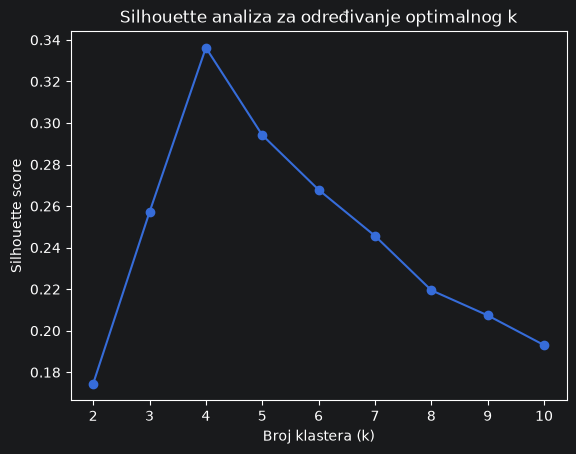

In [49]:
#Pošto elbow metoda ukazuje na k=4 i vidimo blagi lakat na k=8, računamo silhouette score za te i okolne vrednosti k kako bismo imali dodatnu potvrdu izbora optimalnog broja klastera, a ne samo vizuelnu procenu sa grafika

from sklearn.metrics import silhouette_score

silhouette_scores = []
for i in range(2, 11):
    kmeans = cluster.KMeans(n_clusters=i, init="k-means++", n_init=1000, max_iter=100, random_state=0).fit(muski_clanovi)
    score = silhouette_score(muski_clanovi, kmeans.labels_)
    silhouette_scores.append(score)
    print(f"k={i}: silhouette score = {score:.4f}")

plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel("Broj klastera (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette analiza za određivanje optimalnog k")
plt.show()

In [50]:
# Za razliku od osnovne analize (bez Workout_Type) gde je optimalno k=2, ovde silhouette analiza jasno pokazuje da je optimalan broj klastera k=4 (score = 0.3362), sto je znacajno visa vrednost od svih ostalih ispitanih k vrednosti, a sada je vrednost za k=2 dosta niza(0.1745). Ovo pokazuje da ukljucivanje tipa treninga (Workout_Type) otkriva novu podelu clanova u vise grupa. Elbow metoda pokazuje samo lakat oko k=8, ali s obzirom da je silhouette score za tu vrednost znacajno nizi (0.2195), oslanjamo se na silhouette kao objektivniju metriku i biramo k=4
#Vršimo klasterizaciju za k=4:
kmeans = cluster.KMeans(n_clusters = 4, init="k-means++", n_init=1000, max_iter=100, random_state=0).fit(muski_clanovi)

muski_clanovi_clusters = muski_clanovi.copy()
muski_clanovi_clusters["cluster"] = kmeans.labels_

muski_clanovi_clusters.head()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Workout_Type_Cardio,Workout_Type_HIIT,Workout_Type_Strength,Workout_Type_Yoga,cluster
0,0.926829,0.510012,0.275,0.512821,0.755102,0.416667,0.791946,0.084211,0.882353,0.666667,0.0,0.0,0.0,1.0,3
1,0.170732,0.096584,0.250,0.769231,0.897959,0.250000,0.053691,0.936842,0.058824,0.333333,0.0,0.0,1.0,0.0,2
2,0.487805,0.012956,0.475,0.717949,0.775510,0.750000,0.087248,0.957895,0.470588,0.333333,0.0,0.0,1.0,0.0,2
3,0.439024,0.297998,0.300,0.358974,1.000000,0.958333,0.657718,0.542105,0.176471,0.333333,1.0,0.0,0.0,0.0,1
4,0.243902,0.903416,0.850,0.641026,0.142857,0.083333,0.348993,0.942105,0.352941,0.666667,0.0,0.0,1.0,0.0,2


Klaster 1:  114
Klaster 2:  129
Klaster 3:  135
Klaster 4:  133


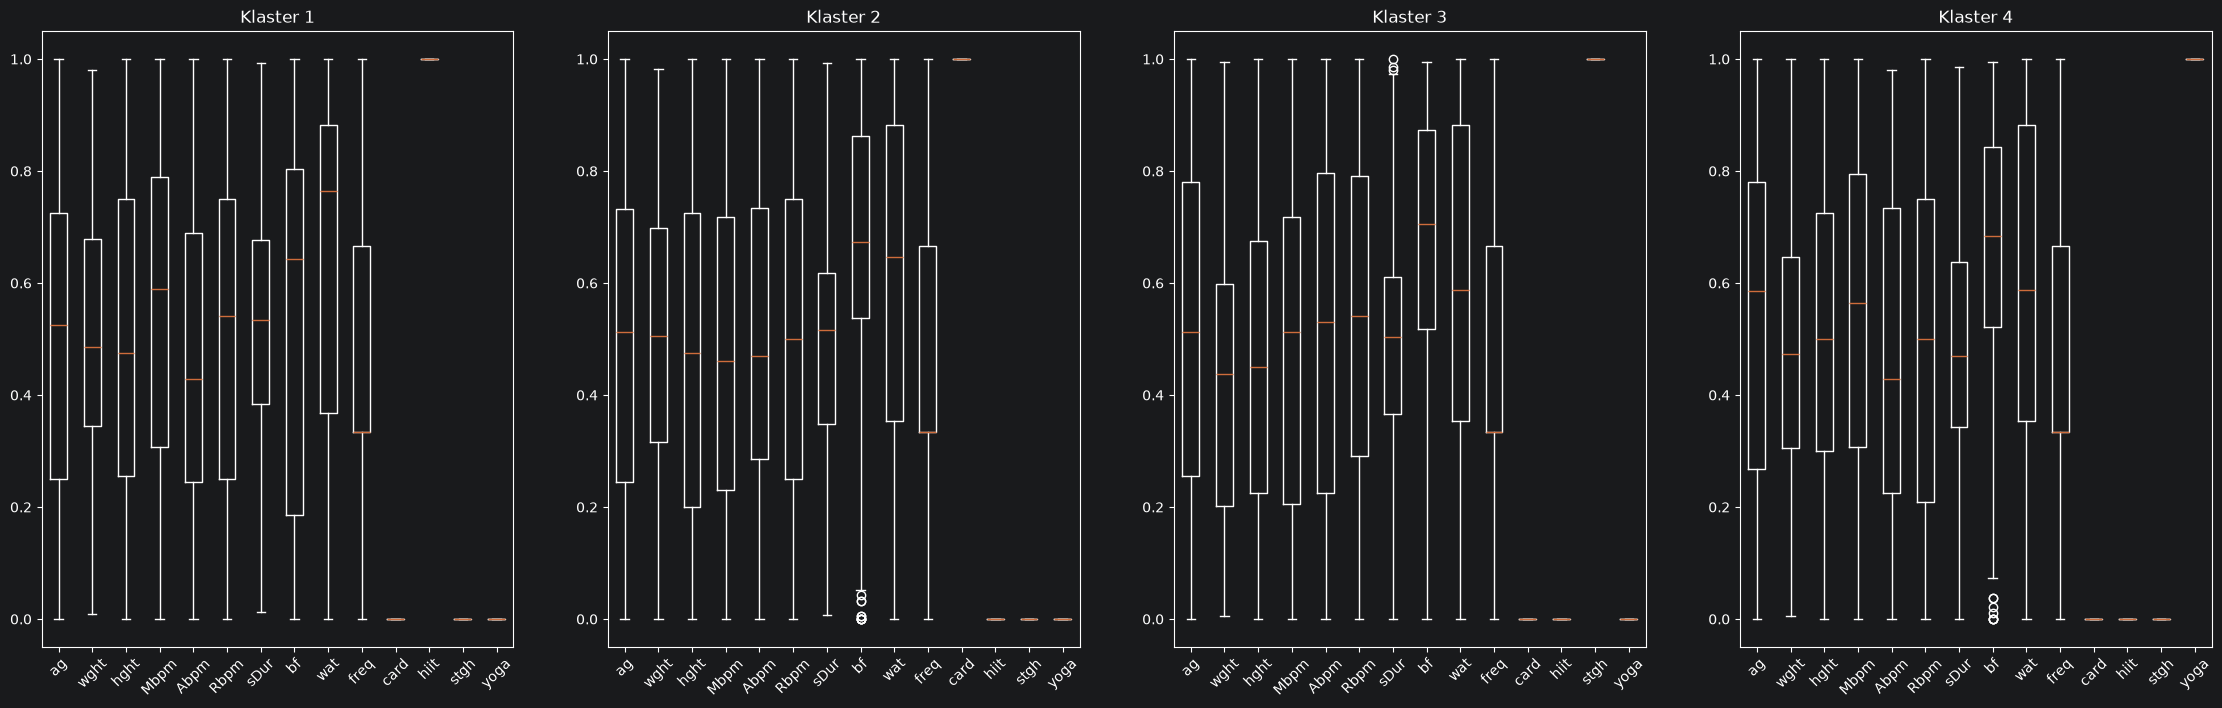

In [51]:
# Nakon klasterizacije za k=4, vršimo tumačenje dobijenih klastera (veličina, centralne vrednosti i disperzija)

fig, ax = plt.subplots(1, 4, figsize=(28, 8))

ax[0].boxplot(muski_clanovi_clusters[muski_clanovi_clusters["cluster"]==0].drop(columns="cluster"), tick_labels = ["ag","wght", "hght", "Mbpm", "Abpm", "Rbpm", "sDur", "bf", "wat", "freq","card","hiit","stgh","yoga"])
ax[0].set_title("Klaster 1")

ax[1].boxplot(muski_clanovi_clusters[muski_clanovi_clusters["cluster"]==1].drop(columns="cluster"), tick_labels = ["ag","wght", "hght", "Mbpm", "Abpm", "Rbpm", "sDur", "bf", "wat", "freq","card","hiit","stgh","yoga"])
ax[1].set_title("Klaster 2")

ax[2].boxplot(muski_clanovi_clusters[muski_clanovi_clusters["cluster"]==2].drop(columns="cluster"), tick_labels = ["ag","wght", "hght", "Mbpm", "Abpm", "Rbpm", "sDur", "bf", "wat", "freq","card","hiit","stgh","yoga"])
ax[2].set_title("Klaster 3")

ax[3].boxplot(muski_clanovi_clusters[muski_clanovi_clusters["cluster"]==3].drop(columns="cluster"), tick_labels = ["ag","wght", "hght", "Mbpm", "Abpm", "Rbpm", "sDur", "bf", "wat", "freq","card","hiit","stgh","yoga"])
ax[3].set_title("Klaster 4")

for a in ax:
    a.tick_params(axis='x', rotation=45)

print("Klaster 1: ", muski_clanovi_clusters.loc[muski_clanovi_clusters["cluster"]==0, "cluster"].count())
print("Klaster 2: ", muski_clanovi_clusters.loc[muski_clanovi_clusters["cluster"]==1, "cluster"].count())
print("Klaster 3: ", muski_clanovi_clusters.loc[muski_clanovi_clusters["cluster"]==2, "cluster"].count())
print("Klaster 4: ", muski_clanovi_clusters.loc[muski_clanovi_clusters["cluster"]==3, "cluster"].count())

# Interpretacija klastera za k=4 (sa ukljucenim Workout_Type):
# Klasteri su znacajne velicine
# Svaki klaster odgovara tacno jednom tipu treninga: Klaster 1 (114 clanova) - iskljucivo HIIT, Klaster 2 (129) - iskljucivo Cardio, Klaster 3 (135) - iskljucivo Strength, Klaster 4 (133) - iskljucivo Yoga. Ostali fizicki parametri (godine, tezina, BPM, procenat masti, trajanje i ucestalost treninga) pokazuju veoma male razlike izmedju klastera, za razliku od osnovne analize bez Workout_Type gde su razlike bile mnogo izrazenije.

# Ovo pokazuje da OHC kolone, postaju dominantan faktor u formiranju klastera, nadjacavajuci uticaj fizickih parametara. Rezultat je da klasterizacija sa ukljucenim Workout_Type prakticno deli clanove na vec poznatu podelu po tipu treninga, umesto da otkrije novu, zasnovanu na fizickim parametrima podelu clanova, sto je bila poenta osnovne analize.

In [52]:
# Poredimo dobijene klastere sa stvarnim nivoom iskustva članova (Experience_Level),koji nije korišćen u samoj klasterizaciji - ovo nam služi kao provera da li klasteri koje je algoritam sam pronašao imaju smisla
muski_clanovi_clusters['Experience_Level'] = experience_level.values
pd.crosstab(muski_clanovi_clusters['cluster'], muski_clanovi_clusters['Experience_Level'])

#Vidimo da cak i nema smisla porediti dobijene klastere sa kolonom "Experience_Level", jer podela na 4 klastera u sustini deli vezbace po tipu treninga, tako da ovo poredjenje pokazuje koliko svaki tip treninga ima pocetnika, srednjih i naprednih vezbaca

Experience_Level,1,2,3
cluster,,,
0,44,40,30
1,50,57,22
2,50,62,23
3,53,54,26


In [53]:
#Iako Silhouette analiza i Elbow metoda pokazuju da je optimalan broj klastera 4, mi ćemo analizirati i slučaj za k=5 i uporediti i te rezultate da bi ispitali da li ce mozda ukoliko se poveca broj klastera, sama podela klastera biti na osnovu fizickih parametara, a ne samo na osnovu tipa treninga
kmeans = cluster.KMeans(n_clusters = 5, init="k-means++", n_init=1000, max_iter=100, random_state=0).fit(muski_clanovi)

muski_clanovi_5clusters = muski_clanovi.copy()
muski_clanovi_5clusters["cluster"] = kmeans.labels_

muski_clanovi_5clusters.head(20)

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Workout_Type_Cardio,Workout_Type_HIIT,Workout_Type_Strength,Workout_Type_Yoga,cluster
0,0.926829,0.510012,0.275,0.512821,0.755102,0.416667,0.791946,0.084211,0.882353,0.666667,0.0,0.0,0.0,1.0,3
1,0.170732,0.096584,0.250,0.769231,0.897959,0.250000,0.053691,0.936842,0.058824,0.333333,0.0,0.0,1.0,0.0,2
2,0.487805,0.012956,0.475,0.717949,0.775510,0.750000,0.087248,0.957895,0.470588,0.333333,0.0,0.0,1.0,0.0,2
3,0.439024,0.297998,0.300,0.358974,1.000000,0.958333,0.657718,0.542105,0.176471,0.333333,1.0,0.0,0.0,0.0,1
4,0.243902,0.903416,0.850,0.641026,0.142857,0.083333,0.348993,0.942105,0.352941,0.666667,0.0,0.0,1.0,0.0,2
5,0.243902,0.669022,0.600,0.230769,0.326531,0.583333,0.382550,0.984211,0.411765,0.333333,1.0,0.0,0.0,0.0,1
6,0.560976,0.892815,0.175,0.717949,0.530612,0.166667,0.208054,0.500000,0.588235,0.000000,0.0,1.0,0.0,0.0,4
7,0.853659,0.078916,0.250,0.384615,0.653061,0.916667,0.429530,0.663158,0.882353,0.333333,0.0,1.0,0.0,0.0,4
8,0.951220,0.795053,0.025,0.897436,0.918367,0.458333,0.489933,0.584211,0.411765,0.333333,1.0,0.0,0.0,0.0,1
9,0.560976,0.583039,1.000,0.487179,0.326531,0.791667,0.449664,0.873684,1.000000,0.333333,0.0,1.0,0.0,0.0,4


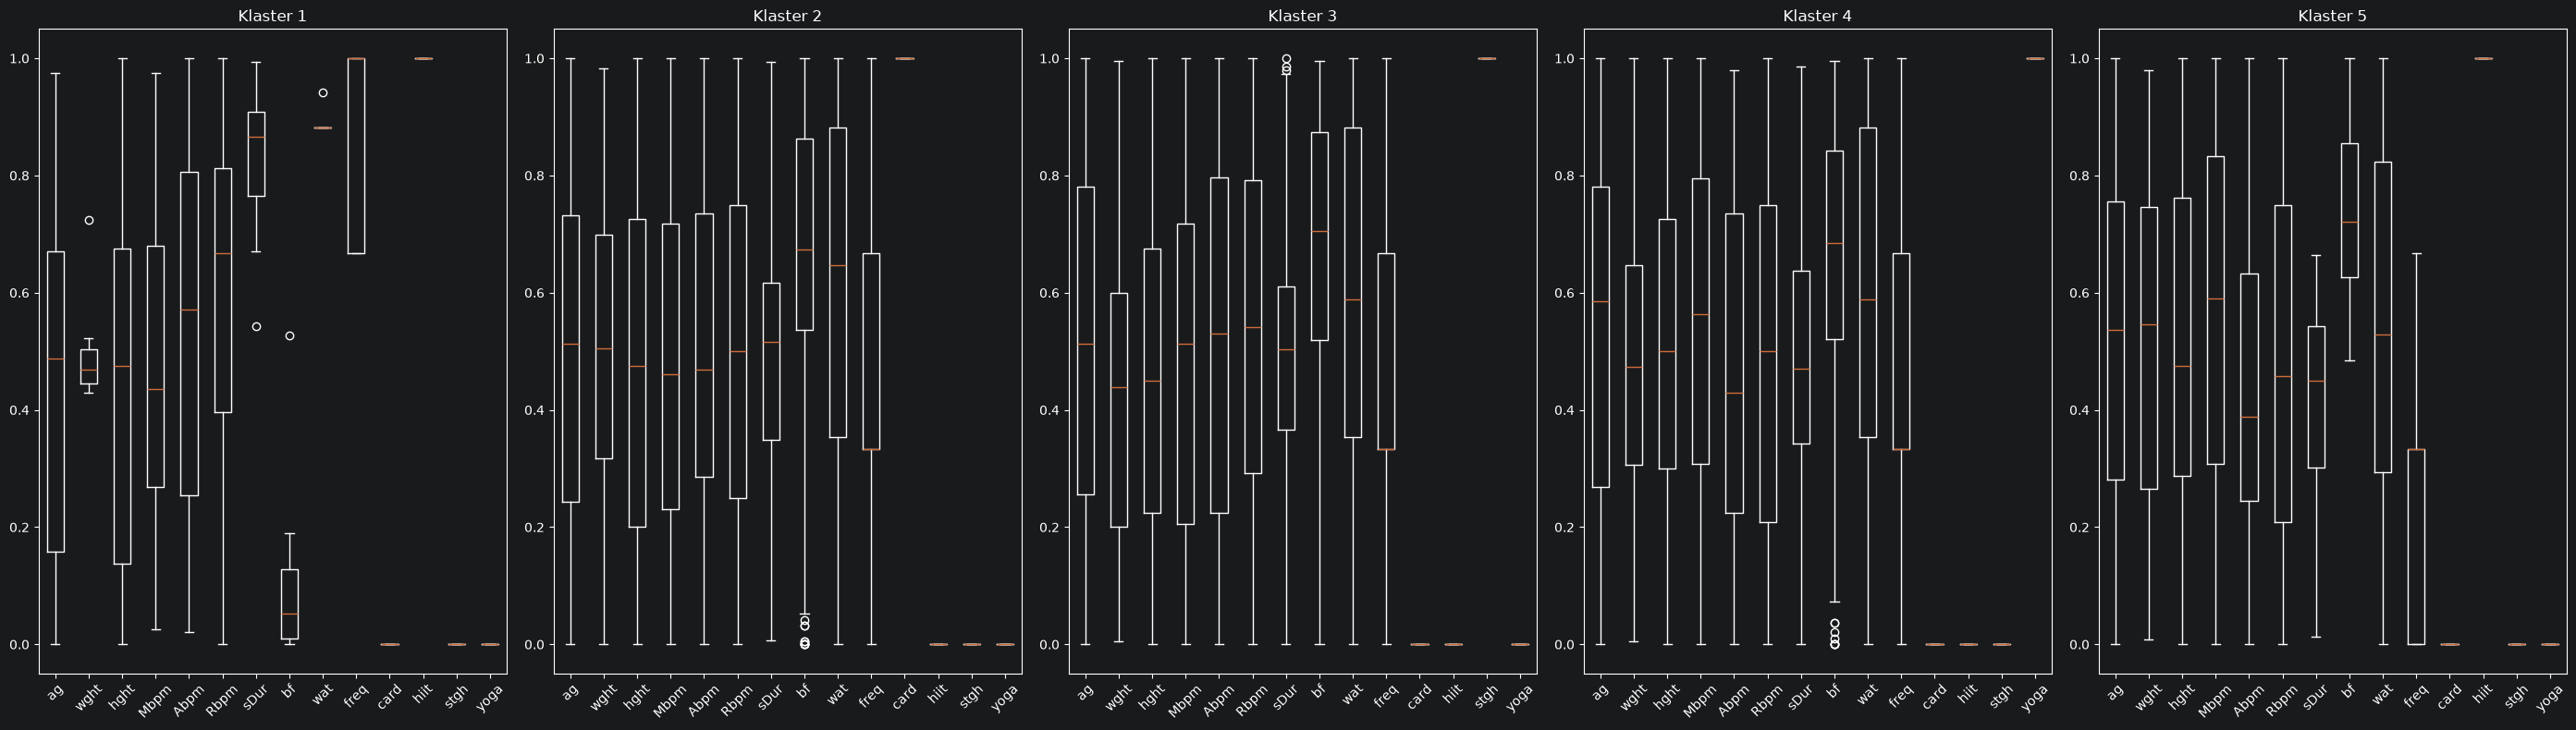

Klaster 1:  31
Klaster 2:  129
Klaster 3:  135
Klaster 4:  133
Klaster 5:  83


In [54]:
fig, ax = plt.subplots(1, 5, figsize=(28, 8))

ax[0].boxplot(muski_clanovi_5clusters[muski_clanovi_5clusters["cluster"]==0].drop(columns=["cluster"]), tick_labels = ["ag","wght", "hght", "Mbpm", "Abpm", "Rbpm", "sDur", "bf", "wat", "freq","card","hiit","stgh","yoga"])
ax[0].set_title("Klaster 1")

ax[1].boxplot(muski_clanovi_5clusters[muski_clanovi_5clusters["cluster"]==1].drop(columns=["cluster"]), tick_labels = ["ag","wght", "hght", "Mbpm", "Abpm", "Rbpm", "sDur", "bf", "wat", "freq","card","hiit","stgh","yoga"])
ax[1].set_title("Klaster 2")

ax[2].boxplot(muski_clanovi_5clusters[muski_clanovi_5clusters["cluster"]==2].drop(columns=["cluster"]), tick_labels = ["ag","wght", "hght", "Mbpm", "Abpm", "Rbpm", "sDur", "bf", "wat", "freq","card","hiit","stgh","yoga"])
ax[2].set_title("Klaster 3")

ax[3].boxplot(muski_clanovi_5clusters[muski_clanovi_5clusters["cluster"]==3].drop(columns=["cluster"]), tick_labels = ["ag","wght", "hght", "Mbpm", "Abpm", "Rbpm", "sDur", "bf", "wat", "freq","card","hiit","stgh","yoga"])
ax[3].set_title("Klaster 4")

ax[4].boxplot(muski_clanovi_5clusters[muski_clanovi_5clusters["cluster"]==4].drop(columns=["cluster"]), tick_labels = ["ag","wght", "hght", "Mbpm", "Abpm", "Rbpm", "sDur", "bf", "wat", "freq","card","hiit","stgh","yoga"])
ax[4].set_title("Klaster 5")

for a in ax:
    a.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Klaster 1: ", muski_clanovi_5clusters.loc[muski_clanovi_5clusters["cluster"]==0, "cluster"].count())
print("Klaster 2: ", muski_clanovi_5clusters.loc[muski_clanovi_5clusters["cluster"]==1, "cluster"].count())
print("Klaster 3: ", muski_clanovi_5clusters.loc[muski_clanovi_5clusters["cluster"]==2, "cluster"].count())
print("Klaster 4: ", muski_clanovi_5clusters.loc[muski_clanovi_5clusters["cluster"]==3, "cluster"].count())
print("Klaster 5: ", muski_clanovi_5clusters.loc[muski_clanovi_5clusters["cluster"]==4, "cluster"].count())
# Klasteri su znacajne velicine
# Klaster 1, cine vezbaci: srednje tezine, duzeg trajanja treninga, niskog procenta telesne masti, visokog unosa vode,visoke frekvencije treninga koji rade hiit treninge
# Klaster 2, cine vezbaci: kojima su svi parametri oko sredine, izuzev nesto veceg procenta masti i unosa vode, koji treniraju cardio treninge
# Klaster 3, cine vezbaci: kojima su svi parametri oko sredine, izuzev nesto veceg procenta masti i unosa vode, koji treniraju treninge snage (strenght)
# Klaster 4, cine vezbaci: kojima su svi parametri oko sredine, izuzev nesto veceg procenta masti i unosa vode, koji treniraju treninge yoge
# Klaster 5, cine vezbaci: sa niskom frekvencijom treninga, kojima su svi ostali parametri oko sredine i treniraju hiit treninge

# Vidimo da klasteri za k=5, ne donose bolju podelu nego za k=4, buduci da ovde sada imamo jedan klaster u kom ima uticaja fizickih parametara ali vidimo da su preostala 4 klastera manje vise ponovo razvrstali vezbace prema tipu treninga kom treniraju

# Takodje poredjenje sa kolonon "Experience_Level" nema nekog smisla jer samo pokazuje koliko vezbaca je pocetnog,srednjeg i naprednog nivoa za svaki tip treninga, izuzev za klaster 1 ali ponovo ni ta nam informacija nista ne znaci jer ostali klasteri nisu zasnovani na fizickim parametrima


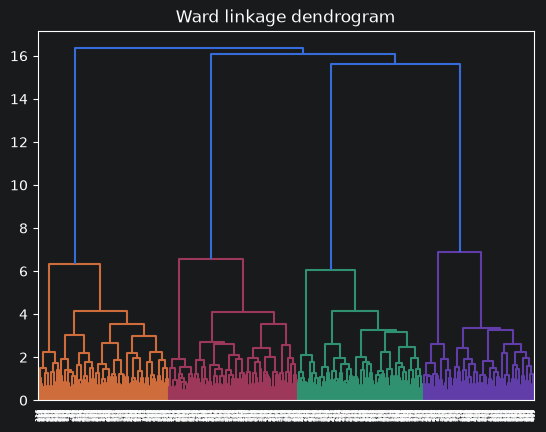

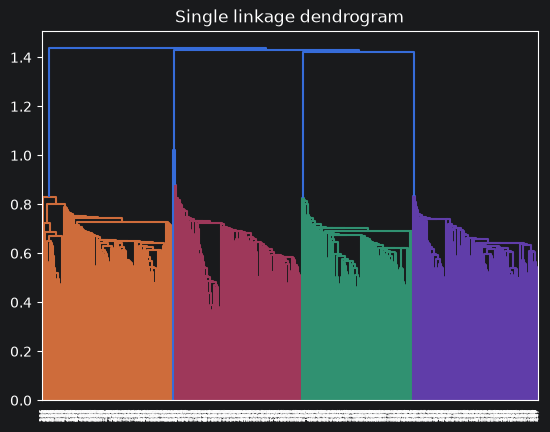

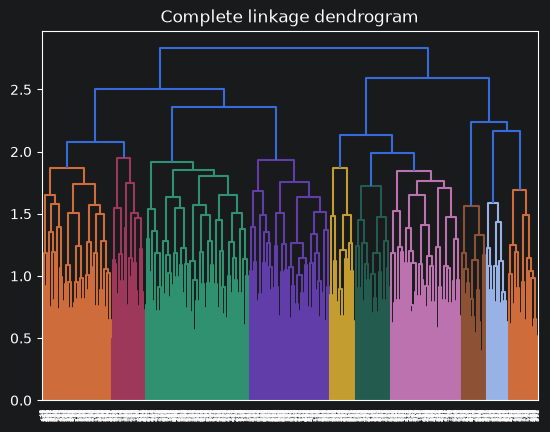

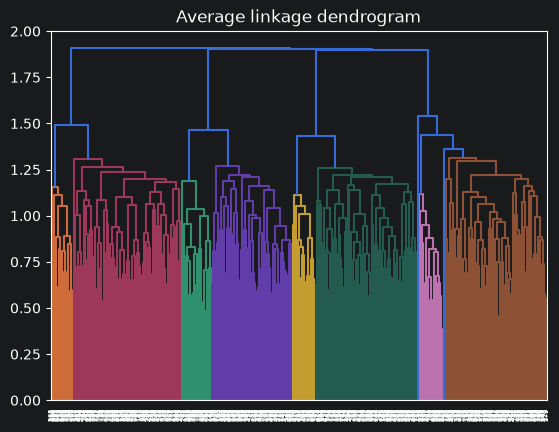

In [55]:
from scipy.cluster.hierarchy import linkage, dendrogram
#Sada prelazimo na hijarahijsku klasterizaciju, prvo što ćemo uraditi jeste crtanje dendrograma sa različitim linkage metodama i euklidskom razdaljinom i određujemo optimalno k
#Prikaz dendrograma za različite linkage metode:
dendrogram(linkage(muski_clanovi, method='ward', metric='euclidean'))
plt.title("Ward linkage dendrogram")
plt.show()

dendrogram(linkage(muski_clanovi, method='single', metric='euclidean'))
plt.title("Single linkage dendrogram")
plt.show()

dendrogram(linkage(muski_clanovi, method='complete', metric='euclidean'))
plt.title("Complete linkage dendrogram")
plt.show()

dendrogram(linkage(muski_clanovi, method='average', metric='euclidean'))
plt.title("Average linkage dendrogram")
plt.show()

In [56]:
# Od ponuđenih metoda, Ward linkage daje ubedljivo najbolju i najjasniju strukturu klastera. Kod Single linkage metode je izražen "chaining" efekat. Complete linkage i Average linkage stvaraju preveliki broj grupa.
# Ward daje najbalansiranije i najčistije klastere, pa je samim tim najpogodniji za dalju analizu i poređenje sa K-Means algoritmom.
#Radimo hijerarhijsku klasterizaciju za 4 klastera i Ward linkage metodom, euklidska udaljenost
hclust = cluster.AgglomerativeClustering(n_clusters=4, linkage = "ward", metric="euclidean").fit(muski_clanovi)

# Pravimo novi dataset i dodajemo kolonu sa vrednostima klastera
h_muski_clanovi = muski_clanovi.copy()
h_muski_clanovi["cluster"] = hclust.labels_
h_muski_clanovi.head()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Workout_Type_Cardio,Workout_Type_HIIT,Workout_Type_Strength,Workout_Type_Yoga,cluster
0,0.926829,0.510012,0.275,0.512821,0.755102,0.416667,0.791946,0.084211,0.882353,0.666667,0.0,0.0,0.0,1.0,2
1,0.170732,0.096584,0.250,0.769231,0.897959,0.250000,0.053691,0.936842,0.058824,0.333333,0.0,0.0,1.0,0.0,1
2,0.487805,0.012956,0.475,0.717949,0.775510,0.750000,0.087248,0.957895,0.470588,0.333333,0.0,0.0,1.0,0.0,1
3,0.439024,0.297998,0.300,0.358974,1.000000,0.958333,0.657718,0.542105,0.176471,0.333333,1.0,0.0,0.0,0.0,3
4,0.243902,0.903416,0.850,0.641026,0.142857,0.083333,0.348993,0.942105,0.352941,0.666667,0.0,0.0,1.0,0.0,1


Klaster 1:  114
Klaster 2:  135
Klaster 3:  133
Klaster 4:  129


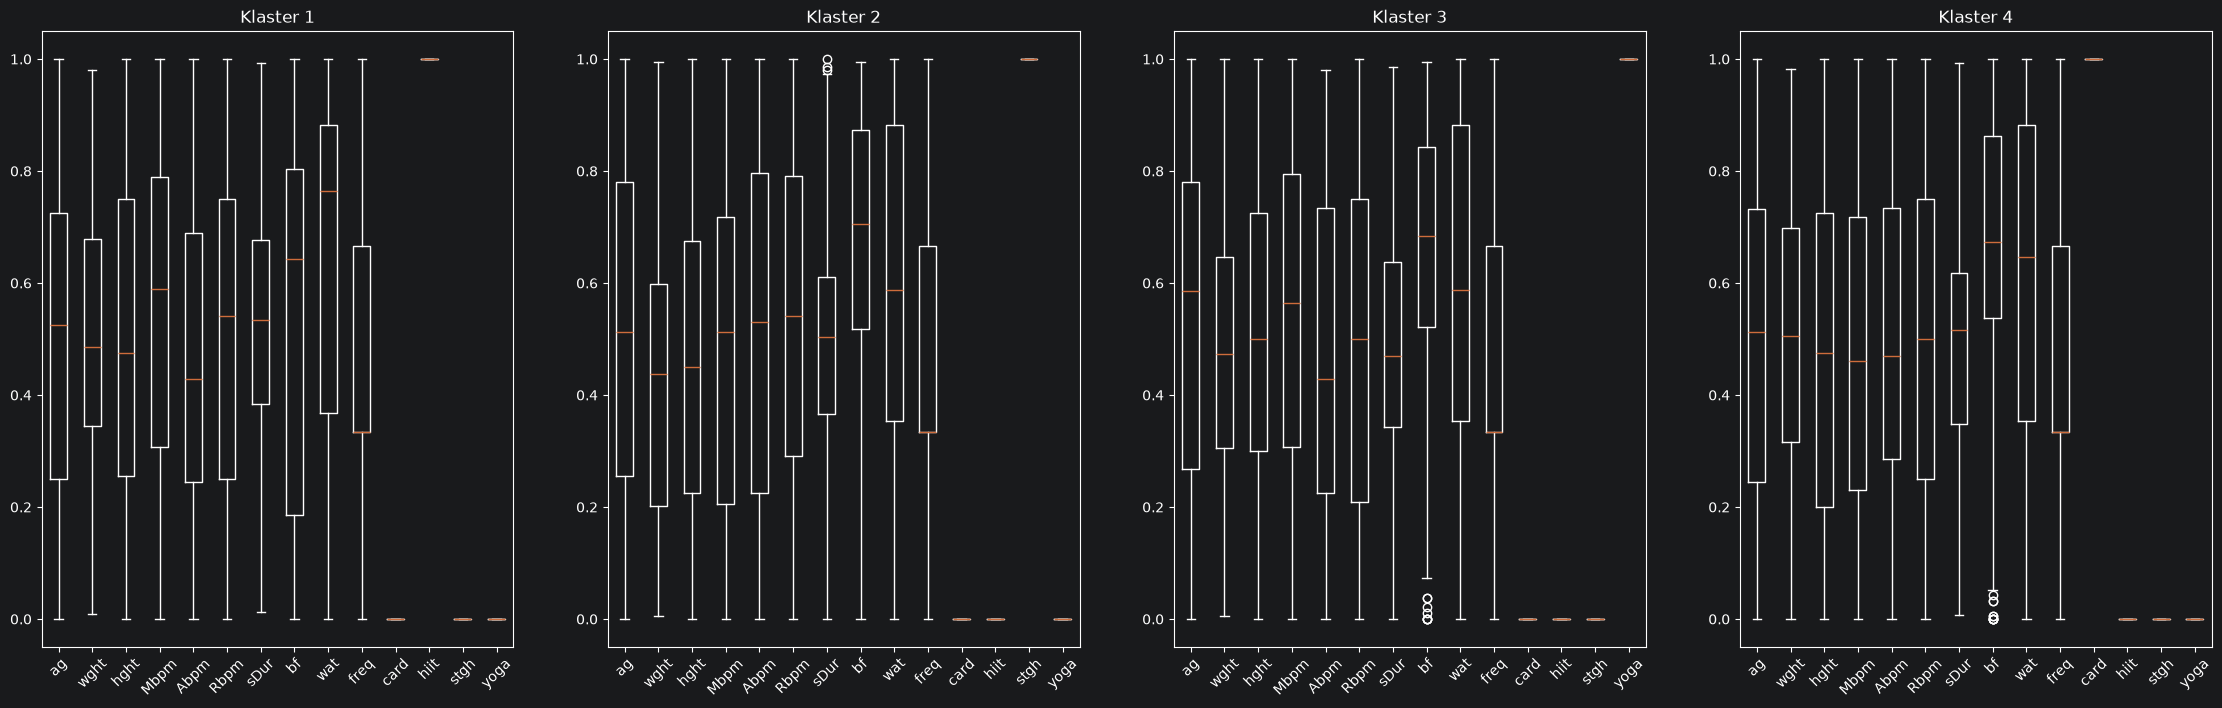

In [57]:
fig, ax = plt.subplots(1, 4, figsize=(28, 8))

ax[0].boxplot(h_muski_clanovi[h_muski_clanovi["cluster"]==0].drop(columns="cluster"), tick_labels = ["ag","wght", "hght", "Mbpm", "Abpm", "Rbpm", "sDur", "bf", "wat", "freq","card","hiit","stgh","yoga"])
ax[0].set_title("Klaster 1")

ax[1].boxplot(h_muski_clanovi[h_muski_clanovi["cluster"]==1].drop(columns="cluster"), tick_labels = ["ag","wght", "hght", "Mbpm", "Abpm", "Rbpm", "sDur", "bf", "wat", "freq","card","hiit","stgh","yoga"])
ax[1].set_title("Klaster 2")

ax[2].boxplot(h_muski_clanovi[h_muski_clanovi["cluster"]==2].drop(columns="cluster"), tick_labels = ["ag","wght", "hght", "Mbpm", "Abpm", "Rbpm", "sDur", "bf", "wat", "freq","card","hiit","stgh","yoga"])
ax[2].set_title("Klaster 3")

ax[3].boxplot(h_muski_clanovi[h_muski_clanovi["cluster"]==3].drop(columns="cluster"), tick_labels = ["ag","wght", "hght", "Mbpm", "Abpm", "Rbpm", "sDur", "bf", "wat", "freq","card","hiit","stgh","yoga"])
ax[3].set_title("Klaster 4")

for a in ax:
    a.tick_params(axis='x', rotation=45)

print("Klaster 1: ", h_muski_clanovi.loc[h_muski_clanovi["cluster"]==0, "cluster"].count())
print("Klaster 2: ", h_muski_clanovi.loc[h_muski_clanovi["cluster"]==1, "cluster"].count())
print("Klaster 3: ", h_muski_clanovi.loc[h_muski_clanovi["cluster"]==2, "cluster"].count())
print("Klaster 4: ", h_muski_clanovi.loc[h_muski_clanovi["cluster"]==3, "cluster"].count())

#Vidimo da su dobijeni klasteri znacajne velicine, ali i da smo dobili potpuno iste klastere kao i za kmeans klasterizaciju - vezbaci su ponovo grupisani samo na osnovu tipa treninga koji treniraju
# Klaster 1: vezbaci hiit treninga
# Klaster 2: vezbaci treninga snage
# Klaster 3: vezbaci treninga yoge
# Klaster 4: vezbaci cardio treninga

In [58]:
# Uporedićemo dobijene klastere sa stvarnim nivoom iskustva članova (Experience_Level),kao i kada smo završili kMeans klasterizaciju


h_muski_clanovi['Experience_Level'] = experience_level.values
pd.crosstab(h_muski_clanovi['cluster'], h_muski_clanovi['Experience_Level'])

# Ovo nam prakticno daje uvid u to koliko svaki trenazni stil ima naprednih,srednjih i vezbaca pocetnika



# Poređenje k-means i hijerarhijske (Ward) klasterizacije:

# Veličine klastera su prakticno iste kao i sami klasteri, reklo bi se da kada se ukljuci promenljiva "Workout_Type" ne dobijamo zeljeni rezultat - klasifikacija clanova teretane na osnovu fizickih parametara, vec dobijamo grupe vezbaca na osnovu tipa treninga kojim se bave, sto nas dovodi do zakljucka da je bolje da samo kolonu izbacimo kao sto smo to uradili i u glavnoj analizi.

Experience_Level,1,2,3
cluster,,,
0,44,40,30
1,50,62,23
2,53,54,26
3,50,57,22
